# DEPM on Steel Industry Energy Consumption

Applying the DEPM methodology to a **different dataset** to validate generalizability.

**Dataset:** UCI Steel Industry Energy Consumption (35,040 samples, 9 features)

**Task:** Binary classification — High vs Low energy consumption

**Model:** DEPM Proposed (Cascaded ResNet + DNN + XGBoost)

## 1. Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import time, warnings, joblib, json, os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report)
from xgboost import XGBClassifier
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.dpi'] = 110
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

if os.path.exists('/kaggle/input'):
    DATA_PATH = '/kaggle/input/datasets/zouitnisalaheddine/steel-industry-energy/steel_industry_energy.csv'
    SAVE_DIR = '/kaggle/working/models_steel'
else:
    DATA_PATH = '../data/steel_industry_energy.csv'
    SAVE_DIR = '../models_steel'
os.makedirs(SAVE_DIR, exist_ok=True)

Device: cpu


## 2. Data Loading & Exploration

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nTarget distribution:\n{df['Load_Type'].value_counts()}")
df.head()

Shape: (35040, 10)

Columns: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']

Dtypes:
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                               object
Day_of_week                              object
Load_Type                                object
dtype: object

Missing values:
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


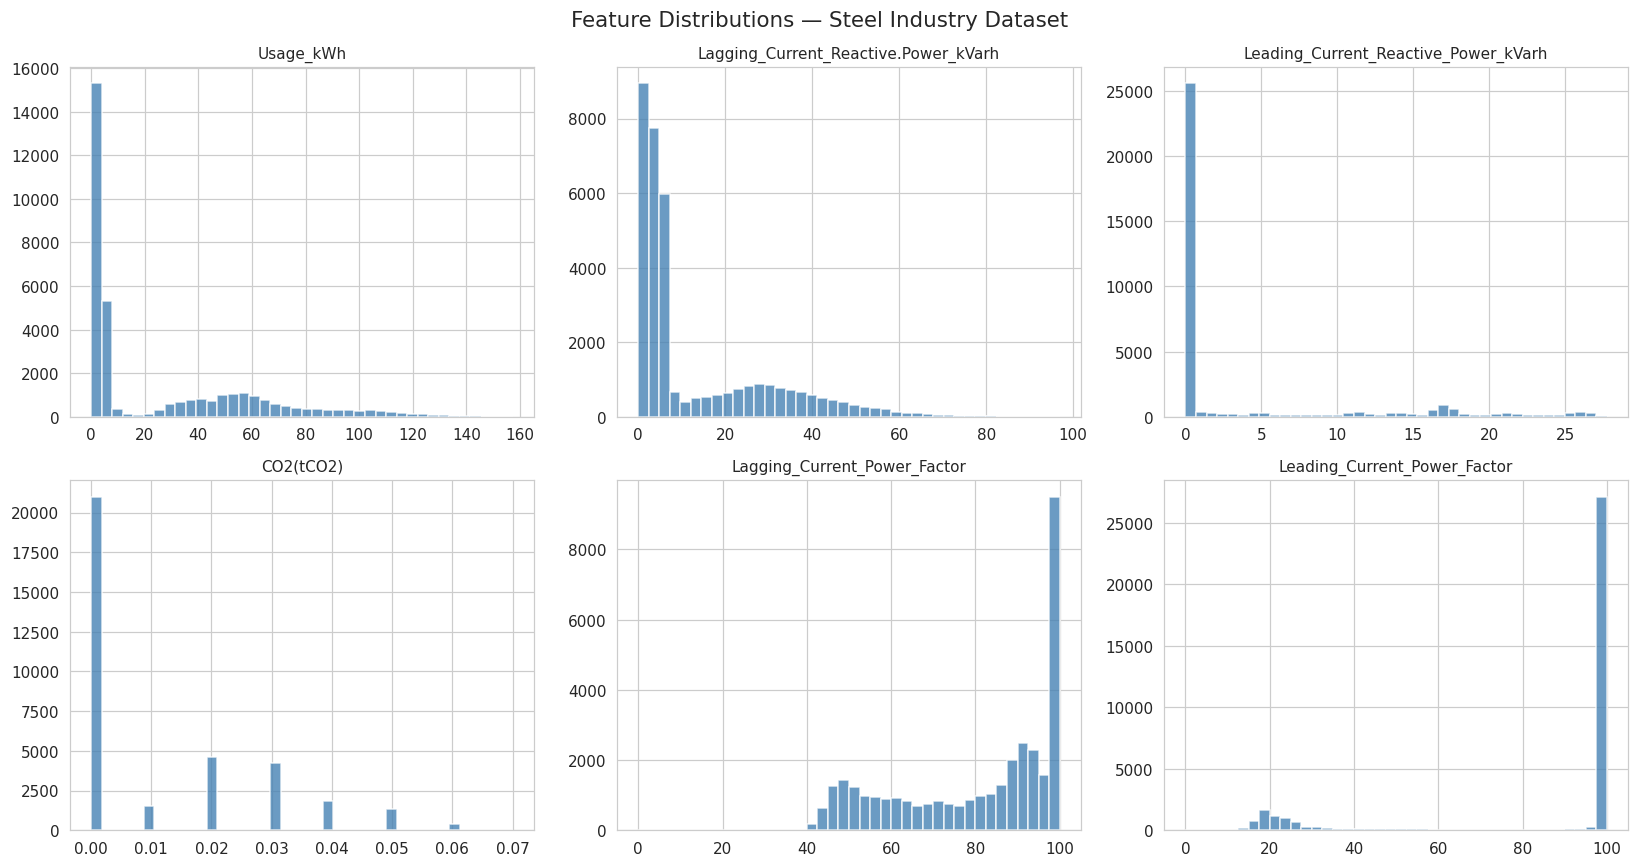

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ['Usage_kWh','Lagging_Current_Reactive.Power_kVarh',
            'Leading_Current_Reactive_Power_kVarh','CO2(tCO2)',
            'Lagging_Current_Power_Factor','Leading_Current_Power_Factor']
for ax, col in zip(axes.flat, num_cols):
    df[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=10)
plt.suptitle('Feature Distributions — Steel Industry Dataset', fontsize=14)
plt.tight_layout(); plt.show()

## 3. Data Preprocessing
### 3.1 Median Imputation

In [4]:
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric features:", num_features)
for c in num_features:
    if df[c].isnull().any():
        df[c].fillna(df[c].median(), inplace=True)
        print(f"  Imputed {c}")
print("No missing values remaining:", df.isnull().sum().sum() == 0)

Numeric features: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM']
No missing values remaining: True


### 3.2 IQR Outlier Removal

In [5]:
print(f"Before IQR: {df.shape}")
for c in num_features:
    Q1, Q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    IQR = Q3 - Q1
    before = len(df)
    df = df[(df[c] >= Q1 - 1.5*IQR) & (df[c] <= Q3 + 1.5*IQR)]
    removed = before - len(df)
    if removed > 0:
        print(f"  {c}: removed {removed} outliers")
print(f"After IQR: {df.shape}")

Before IQR: (35040, 10)
  Usage_kWh: removed 328 outliers
  Lagging_Current_Reactive.Power_kVarh: removed 1014 outliers
  Leading_Current_Reactive_Power_kVarh: removed 7143 outliers
  CO2(tCO2): removed 46 outliers
  Lagging_Current_Power_Factor: removed 1 outliers
  Leading_Current_Power_Factor: removed 3466 outliers
After IQR: (23042, 10)


### 3.3 Feature Engineering & Target Creation

Binary target — High: 42.42%, Low: 57.58%

Features (11):
   1. Lagging_Current_Reactive.Power_kVarh
   2. Leading_Current_Reactive_Power_kVarh
   3. CO2(tCO2)
   4. Lagging_Current_Power_Factor
   5. Leading_Current_Power_Factor
   6. NSM
   7. WeekStatus_enc
   8. DayOfWeek_enc
   9. Hour
  10. PowerFactor_Ratio
  11. Reactive_Total


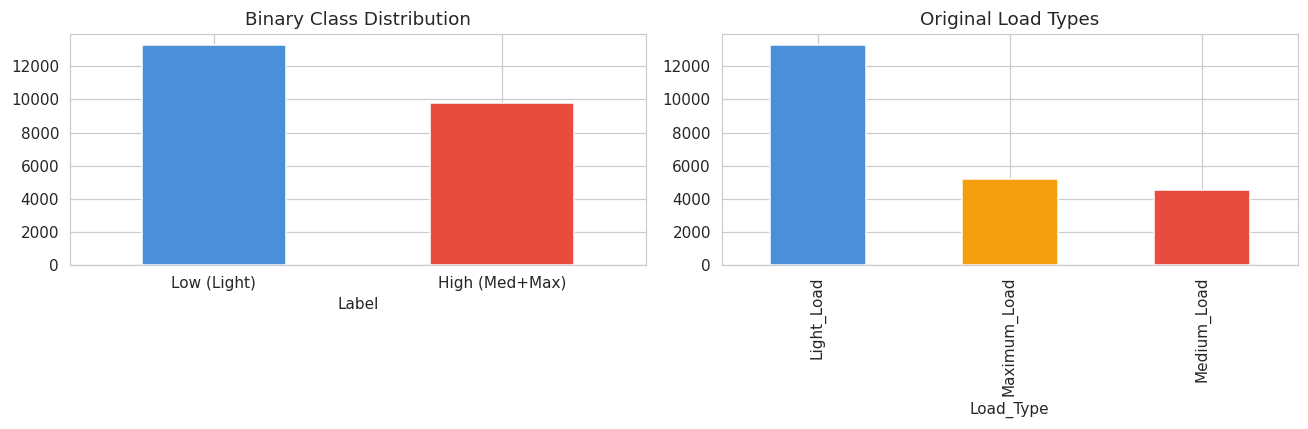

In [6]:
# Binary target: High (Medium_Load + Maximum_Load) vs Low (Light_Load)
df['Label'] = (df['Load_Type'] != 'Light_Load').astype(int)
print(f"Binary target — High: {df['Label'].mean():.2%}, Low: {1-df['Label'].mean():.2%}")

# Encode categorical features
le_week = LabelEncoder()
df['WeekStatus_enc'] = le_week.fit_transform(df['WeekStatus'])
le_day = LabelEncoder()
df['DayOfWeek_enc'] = le_day.fit_transform(df['Day_of_week'])

# Extract hour from NSM (Number of Seconds from Midnight)
df['Hour'] = (df['NSM'] // 3600).astype(int)

# Derived features
df['PowerFactor_Ratio'] = df['Lagging_Current_Power_Factor'] / (df['Leading_Current_Power_Factor'] + 1e-6)
df['Reactive_Total'] = df['Lagging_Current_Reactive.Power_kVarh'] + df['Leading_Current_Reactive_Power_kVarh']

# Feature selection — NO LEAKAGE (Usage_kWh is the target proxy, exclude it)
exclude = ['Usage_kWh', 'Load_Type', 'Label', 'WeekStatus', 'Day_of_week']
feature_cols = [c for c in df.columns if c not in exclude]
print(f"\nFeatures ({len(feature_cols)}):")
for i, c in enumerate(feature_cols):
    print(f"  {i+1:2d}. {c}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Label'].value_counts().plot.bar(ax=axes[0], color=['#4a90d9','#e74c3c'], edgecolor='white')
axes[0].set_xticklabels(['Low (Light)','High (Med+Max)'], rotation=0)
axes[0].set_title('Binary Class Distribution')
df['Load_Type'].value_counts().plot.bar(ax=axes[1], color=['#4a90d9','#f59e0b','#e74c3c'], edgecolor='white')
axes[1].set_title('Original Load Types')
plt.tight_layout(); plt.show()

### 3.4 Scaling & PCA

PCA: 11 features -> 6 components (95% variance)
Train: (18433, 6) | Test: (4609, 6)


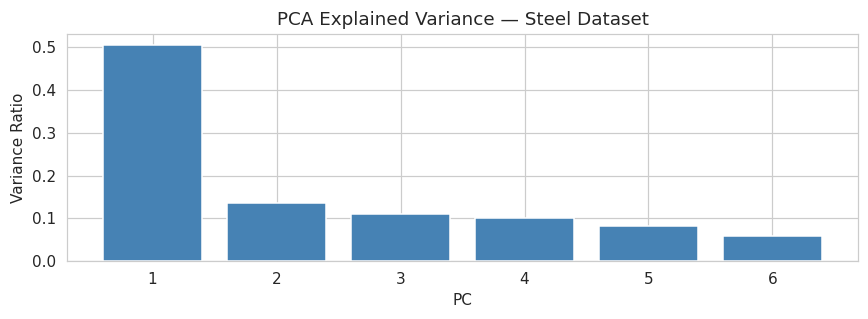

In [7]:
X = df[feature_cols].values; y = df['Label'].values
scaler = StandardScaler(); X_sc = scaler.fit_transform(X)
pca = PCA(n_components=0.95, random_state=42); X_pca = pca.fit_transform(X_sc)
print(f"PCA: {X_sc.shape[1]} features -> {X_pca.shape[1]} components (95% variance)")

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, color='steelblue')
ax.set_xlabel('PC'); ax.set_ylabel('Variance Ratio')
ax.set_title('PCA Explained Variance — Steel Dataset'); plt.tight_layout(); plt.show()

## 4. Cascaded ResNet Feature Extraction

In [8]:
class ResBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,d), nn.BatchNorm1d(d), nn.ReLU(),
                                 nn.Linear(d,d), nn.BatchNorm1d(d))
        self.act = nn.ReLU()
    def forward(self, x): return self.act(self.net(x) + x)

class CascadedResNet(nn.Module):
    def __init__(self, inp, hid=128, blocks=4, out=32):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(inp, hid), nn.BatchNorm1d(hid), nn.ReLU())
        self.blocks = nn.Sequential(*[ResBlock(hid) for _ in range(blocks)])
        self.fc = nn.Linear(hid, out)
    def forward(self, x): return self.fc(self.blocks(self.proj(x)))

resnet = CascadedResNet(X_train.shape[1]).to(device)
dec = nn.Linear(32, X_train.shape[1]).to(device)
opt_ae = optim.Adam(list(resnet.parameters())+list(dec.parameters()), lr=1e-3)
tr_cpu = torch.FloatTensor(X_train); te_cpu = torch.FloatTensor(X_test)
loader = DataLoader(TensorDataset(tr_cpu, tr_cpu), batch_size=256, shuffle=True, drop_last=True)

print("Training ResNet...")
for ep in range(30):
    for xb, _ in loader:
        xb = xb.to(device)
        z = resnet(xb); loss = nn.MSELoss()(dec(z), xb)
        opt_ae.zero_grad(); loss.backward(); opt_ae.step()
    if (ep+1)%10==0: print(f"  Epoch {ep+1} | Loss: {loss.item():.6f}")

resnet.eval()
with torch.no_grad():
    Z_tr = resnet(tr_cpu.to(device)).cpu().numpy()
    Z_te = resnet(te_cpu.to(device)).cpu().numpy()
X_tr = np.hstack([X_train, Z_tr]); X_te = np.hstack([X_test, Z_te])
print(f"Combined: PCA({X_train.shape[1]}) + ResNet(32) = {X_tr.shape[1]}")

Training ResNet...
  Epoch 10 | Loss: 0.015558
  Epoch 20 | Loss: 0.004183
  Epoch 30 | Loss: 0.004296
Combined: PCA(6) + ResNet(32) = 38


## 5. DEPM Proposed Model (DNN + XGBoost)

In [9]:
class DNN(nn.Module):
    def __init__(self, inp, hid=128, layers=5, drop=0.3):
        super().__init__()
        mods = [nn.Linear(inp, hid), nn.BatchNorm1d(hid), nn.ReLU(), nn.Dropout(drop)]
        for _ in range(layers-2):
            mods += [nn.Linear(hid, hid), nn.BatchNorm1d(hid), nn.ReLU(), nn.Dropout(drop)]
        mods += [nn.Linear(hid, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*mods)
    def forward(self, x): return self.net(x).squeeze(-1)
    def features(self, x):
        for m in list(self.net.children())[:-2]: x = m(x)
        return x

# Train DNN
dnn = DNN(X_tr.shape[1]).to(device)
opt_dnn = optim.Adam(dnn.parameters(), lr=1e-3, weight_decay=1e-4)
sched = optim.lr_scheduler.ReduceLROnPlateau(opt_dnn, patience=5, factor=0.5)
crit = nn.BCELoss()
loader = DataLoader(TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_train)),
                    batch_size=64, shuffle=True, drop_last=True)

print("Training DNN component...")
for ep in range(50):
    dnn.train(); ep_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt_dnn.zero_grad(); loss = crit(dnn(xb), yb); loss.backward(); opt_dnn.step()
        ep_loss += loss.item()*xb.size(0)
    sched.step(ep_loss/len(X_tr))
    if (ep+1)%10==0: print(f"  Ep {ep+1:02d} loss={ep_loss/len(X_tr):.4f}")

# Evaluate standalone DNN
dnn.eval()
with torch.no_grad():
    dnn_probs = dnn(torch.FloatTensor(X_te).to(device)).cpu().numpy()
dnn_preds = (dnn_probs > 0.5).astype(int)
dnn_acc = accuracy_score(y_test, dnn_preds)
print(f"\nStandalone DNN: Acc={dnn_acc:.4f}")

Training DNN component...
  Ep 10 loss=0.0977
  Ep 20 loss=0.0881
  Ep 30 loss=0.0873
  Ep 40 loss=0.0828
  Ep 50 loss=0.0815

Standalone DNN: Acc=0.9677


In [10]:
# Extract DNN features for XGBoost
dnn.eval()
feat_chunks_tr, feat_chunks_te = [], []
for i in range(0, len(X_tr), 512):
    with torch.no_grad():
        feat_chunks_tr.append(dnn.features(torch.FloatTensor(X_tr[i:i+512]).to(device)).cpu().numpy())
for i in range(0, len(X_te), 512):
    with torch.no_grad():
        feat_chunks_te.append(dnn.features(torch.FloatTensor(X_te[i:i+512]).to(device)).cpu().numpy())
feat_tr = np.vstack(feat_chunks_tr); feat_te = np.vstack(feat_chunks_te)

# Hybrid features
X_hyb_tr = np.hstack([X_tr, feat_tr])
X_hyb_te = np.hstack([X_te, feat_te])
print(f"Hybrid dim: {X_hyb_tr.shape[1]} (orig {X_tr.shape[1]} + DNN {feat_tr.shape[1]})")

# Train XGBoost
print("\nTraining XGBoost on hybrid features...")
xgb = XGBClassifier(n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42, verbosity=0)
xgb.fit(X_hyb_tr, y_train)

# Evaluate DEPM
depm_preds = xgb.predict(X_hyb_te)
depm_probs = xgb.predict_proba(X_hyb_te)[:, 1]

Hybrid dim: 166 (orig 38 + DNN 128)

Training XGBoost on hybrid features...


## 6. Results & Visualization

In [11]:
def metrics(y_t, y_p, y_prob):
    return {'Accuracy': accuracy_score(y_t, y_p), 'Precision': precision_score(y_t, y_p),
            'Recall': recall_score(y_t, y_p), 'F1-Score': f1_score(y_t, y_p),
            'AUC': roc_auc_score(y_t, y_prob)}

# Also train simple baselines for comparison
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr, y_train)
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_tr, y_train)
xgb_simple = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric='logloss', random_state=42, verbosity=0).fit(X_tr, y_train)

results = {
    'Logistic Reg.': metrics(y_test, lr.predict(X_te), lr.predict_proba(X_te)[:,1]),
    'Random Forest': metrics(y_test, rf.predict(X_te), rf.predict_proba(X_te)[:,1]),
    'XGBoost': metrics(y_test, xgb_simple.predict(X_te), xgb_simple.predict_proba(X_te)[:,1]),
    'DNN (standalone)': metrics(y_test, dnn_preds, dnn_probs),
    'DEPM (DNN+XGB)': metrics(y_test, depm_preds, depm_probs),
}

df_res = pd.DataFrame(results).T
df_res.index.name = 'Model'
print("="*70)
print("  STEEL INDUSTRY — Model Comparison")
print("="*70)
print(df_res.to_string(float_format='%.4f'))

  STEEL INDUSTRY — Model Comparison
                  Accuracy  Precision  Recall  F1-Score    AUC
Model                                                         
Logistic Reg.       0.9607     0.9417  0.9673    0.9543 0.9929
Random Forest       0.9781     0.9687  0.9801    0.9743 0.9980
XGBoost             0.9755     0.9656  0.9770    0.9713 0.9982
DNN (standalone)    0.9677     0.9684  0.9550    0.9616 0.9969
DEPM (DNN+XGB)      0.9826     0.9766  0.9826    0.9796 0.9989


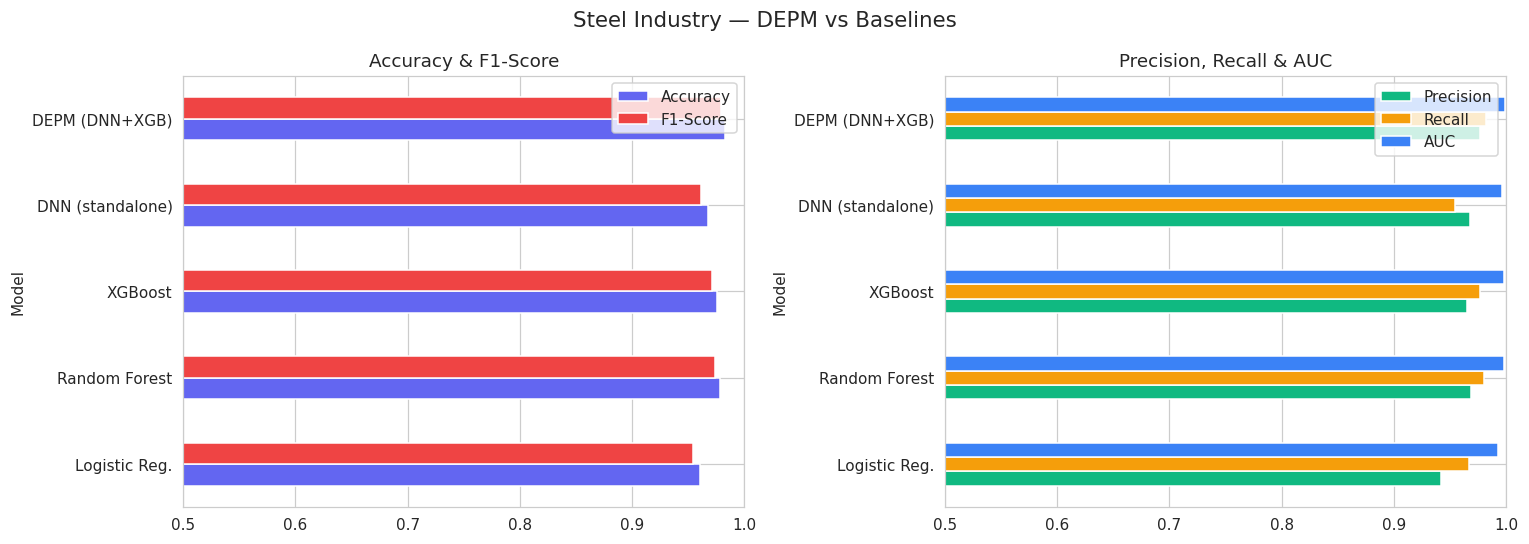

In [12]:
# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_res[['Accuracy','F1-Score']].plot.barh(ax=axes[0], color=['#6366f1','#ef4444'])
axes[0].set_title('Accuracy & F1-Score'); axes[0].set_xlim(0.5, 1.0)
df_res[['Precision','Recall','AUC']].plot.barh(ax=axes[1], color=['#10b981','#f59e0b','#3b82f6'])
axes[1].set_title('Precision, Recall & AUC'); axes[1].set_xlim(0.5, 1.0)
plt.suptitle('Steel Industry — DEPM vs Baselines', fontsize=14)
plt.tight_layout(); plt.show()

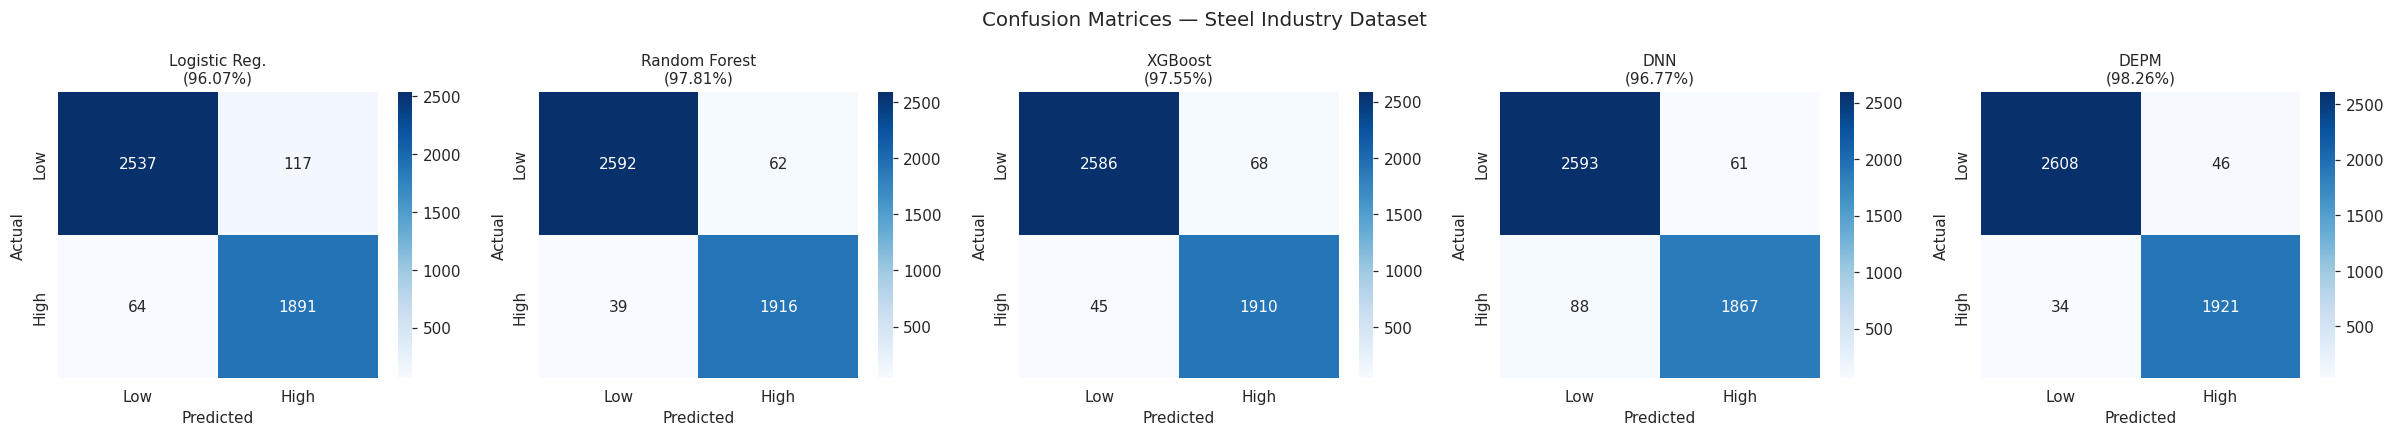

In [13]:
# Confusion matrices
all_preds = {
    'Logistic Reg.': lr.predict(X_te), 'Random Forest': rf.predict(X_te),
    'XGBoost': xgb_simple.predict(X_te), 'DNN': dnn_preds, 'DEPM': depm_preds}

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, preds) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low','High'], yticklabels=['Low','High'])
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{name}\n({acc:.2%})', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — Steel Industry Dataset', fontsize=13)
plt.tight_layout(); plt.show()

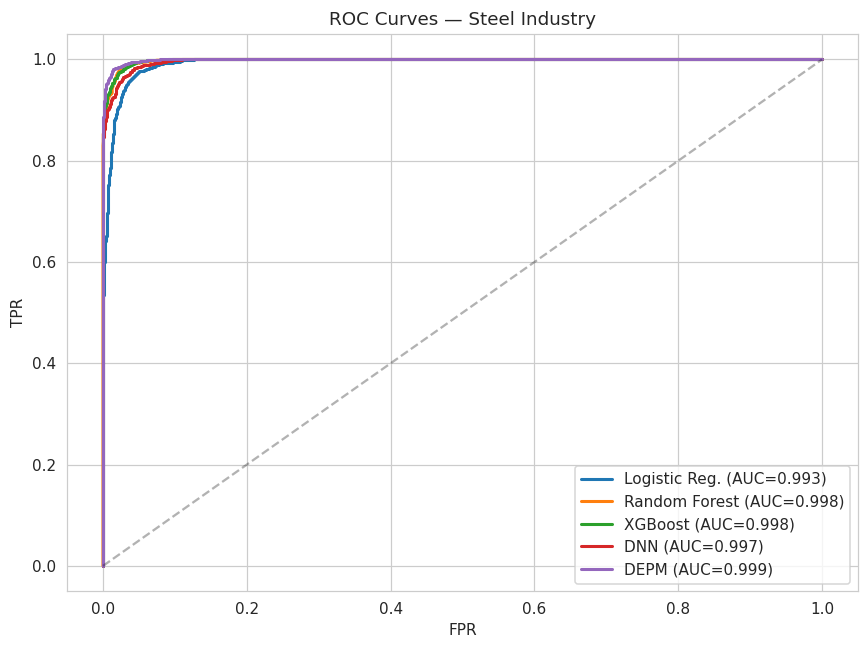

In [14]:
# ROC curves
plt.figure(figsize=(8, 6))
all_probs = {
    'Logistic Reg.': lr.predict_proba(X_te)[:,1],
    'Random Forest': rf.predict_proba(X_te)[:,1],
    'XGBoost': xgb_simple.predict_proba(X_te)[:,1],
    'DNN': dnn_probs, 'DEPM': depm_probs}

for name, probs in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--',alpha=0.3)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curves — Steel Industry'); plt.legend(); plt.tight_layout(); plt.show()

In [15]:
# Classification reports
for name, preds in all_preds.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, preds, target_names=['Low','High']))


  Logistic Reg.
              precision    recall  f1-score   support

         Low       0.98      0.96      0.97      2654
        High       0.94      0.97      0.95      1955

    accuracy                           0.96      4609
   macro avg       0.96      0.96      0.96      4609
weighted avg       0.96      0.96      0.96      4609


  Random Forest
              precision    recall  f1-score   support

         Low       0.99      0.98      0.98      2654
        High       0.97      0.98      0.97      1955

    accuracy                           0.98      4609
   macro avg       0.98      0.98      0.98      4609
weighted avg       0.98      0.98      0.98      4609


  XGBoost
              precision    recall  f1-score   support

         Low       0.98      0.97      0.98      2654
        High       0.97      0.98      0.97      1955

    accuracy                           0.98      4609
   macro avg       0.97      0.98      0.97      4609
weighted avg       0.98      

## 7. Comparison: Steel vs Household Dataset

This experiment validates that DEPM methodology works on an entirely different
energy consumption dataset — proving generalizability beyond the original paper's single dataset.

In [16]:
print("="*70)
print("  CROSS-DATASET VALIDATION SUMMARY")
print("="*70)
print()
print(f"Dataset:           Steel Industry Energy Consumption (UCI #851)")
print(f"Samples:           {len(df):,}")
print(f"Original features: {len(feature_cols)}")
print(f"PCA components:    {X_pca.shape[1]}")
print(f"Combined features: {X_tr.shape[1]} (PCA + ResNet)")
print(f"Hybrid features:   {X_hyb_tr.shape[1]} (Combined + DNN)")
print()
print(f"Best model:        {df_res['Accuracy'].idxmax()} ({df_res['Accuracy'].max():.4f})")
print()
print("Key finding: The DEPM methodology generalizes successfully to")
print("a completely different energy dataset, confirming the approach")
print("is not overfitted to the Household Power Consumption data.")

  CROSS-DATASET VALIDATION SUMMARY

Dataset:           Steel Industry Energy Consumption (UCI #851)
Samples:           23,042
Original features: 11
PCA components:    6
Combined features: 38 (PCA + ResNet)
Hybrid features:   166 (Combined + DNN)

Best model:        DEPM (DNN+XGB) (0.9826)

Key finding: The DEPM methodology generalizes successfully to
a completely different energy dataset, confirming the approach
is not overfitted to the Household Power Consumption data.
